Dataset Sleep Health and Lifestyle berisi informasi mengenai kondisi kesehatan dan gaya hidup individu yang berkaitan dengan kualitas tidur. Variabel yang terdapat dalam dataset meliputi karakteristik demografis (seperti usia dan gender), kebiasaan hidup (aktivitas fisik, jumlah langkah harian), serta indikator kesehatan (BMI, tekanan darah, detak jantung).

Dataset ini bertujuan untuk menganalisis hubungan antara gaya hidup dan kualitas tidur, serta mengidentifikasi faktor-faktor yang mempengaruhi gangguan tidur (sleep disorder).

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

df.head()

Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (2).csv


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Output dari kode tersebut menampilkan lima baris pertama dari dataset yang telah upload. Tujuannya adalah untuk melihat struktur awal data, seperti nama kolom dan isi data secara umum. Langkah ini membantu memahami kondisi dataset sebelum dilakukan proses preprocessing.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


Output dari `df.info()` menunjukkan informasi umum mengenai struktur dataset. Dataset terdiri dari 374 data dengan 13 kolom. Setiap kolom memiliki tipe data yang berbeda, yaitu numerik (int64 dan float64) serta kategorik (object).

Dari output tersebut juga terlihat bahwa sebagian besar kolom tidak memiliki missing value, kecuali pada kolom *Sleep Disorder* yang hanya memiliki 155 data terisi. Hal ini menunjukkan adanya data kosong pada kolom tersebut yang perlu ditangani pada tahap preprocessing.

In [28]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


Output dari `df.describe()` menampilkan ringkasan statistik deskriptif dari variabel numerik dalam dataset. Informasi yang ditampilkan meliputi jumlah data (count), nilai rata-rata (mean), standar deviasi (std), nilai minimum (min), kuartil (25%, 50%, 75%), dan nilai maksimum (max).

Dari hasil tersebut dapat diketahui bahwa data memiliki sebaran yang cukup bervariasi, misalnya pada variabel *Daily Steps* yang memiliki rentang nilai cukup besar dari 3000 hingga 10000. Selain itu, nilai rata-rata pada setiap variabel juga memberikan gambaran umum kondisi data.

Output ini digunakan untuk memahami distribusi data dan membantu mendeteksi adanya nilai yang tidak wajar sebelum dilakukan proses preprocessing lebih lanjut.

In [29]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [31]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')

df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


Output tersebut menunjukkan bahwa setelah dilakukan pengisian missing value pada kolom *Sleep Disorder*, seluruh kolom dalam dataset sudah tidak memiliki data kosong (missing value).

Hal ini terlihat dari nilai 0 pada setiap kolom hasil `isnull().sum()`, yang berarti semua data telah terisi dengan lengkap. Dengan demikian, dataset sudah bersih dari missing value dan siap untuk diproses pada tahap selanjutnya.

In [32]:
df[['Systolic','Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)

df.drop('Blood Pressure', axis=1, inplace=True)

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


Output tersebut menunjukkan bahwa kolom *Blood Pressure* yang sebelumnya berbentuk teks (misalnya 120/80) telah berhasil dipisahkan menjadi dua kolom baru, yaitu *Systolic* dan *Diastolic*. Kedua kolom tersebut juga sudah diubah ke dalam bentuk numerik (integer) sehingga dapat digunakan dalam analisis.

Selain itu, kolom *Blood Pressure* yang lama telah dihapus karena informasinya sudah diwakili oleh dua kolom baru tersebut. Dengan demikian, struktur data menjadi lebih rapi dan seluruh nilai tekanan darah sudah dalam format yang lebih mudah diolah.

In [33]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,0,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,2,0,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,3,0,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
3,4,0,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,0,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


Output tersebut menunjukkan bahwa variabel *Gender* yang sebelumnya berbentuk teks telah berhasil diubah menjadi bentuk numerik. Nilai "Male" dikonversi menjadi 0, sedangkan "Female" dikonversi menjadi 1.

Perubahan ini dilakukan agar data dapat diproses dalam analisis, karena sebagian besar metode pengolahan data memerlukan input dalam bentuk angka. Dengan demikian, variabel Gender sudah siap digunakan pada tahap analisis selanjutnya.

In [34]:
df = pd.get_dummies(df, columns=['Occupation','BMI Category','Sleep Disorder'])

df.head()

,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,...,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_No Disorder,Sleep Disorder_Sleep Apnea
0,1,0,27,6.1,6,42,6,77,4200,126,...,False,True,False,False,False,False,True,False,True,False
1,2,0,28,6.2,6,60,8,75,10000,125,...,False,False,False,True,False,False,False,False,True,False
2,3,0,28,6.2,6,60,8,75,10000,125,...,False,False,False,True,False,False,False,False,True,False
3,4,0,28,5.9,4,30,8,85,3000,140,...,False,False,False,False,False,True,False,False,False,True
4,5,0,28,5.9,4,30,8,85,3000,140,...,False,False,False,False,False,True,False,False,False,True


Output tersebut menunjukkan bahwa variabel kategorik seperti *Occupation*, *BMI Category*, dan *Sleep Disorder* telah diubah menjadi beberapa kolom baru menggunakan metode one-hot encoding.

Setiap kategori direpresentasikan dalam bentuk kolom biner dengan nilai True/False (atau 1/0), yang menunjukkan apakah suatu data termasuk dalam kategori tersebut atau tidak. Akibatnya, jumlah kolom dalam dataset bertambah karena setiap kategori memiliki kolom sendiri.

Dengan perubahan ini, seluruh data kategorik telah diubah menjadi numerik sehingga dapat digunakan dalam proses analisis atau pemodelan.

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age','Sleep Duration','Heart Rate','Daily Steps']] = scaler.fit_transform(
    df[['Age','Sleep Duration','Heart Rate','Daily Steps']]
)

df.head()

,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,...,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_No Disorder,Sleep Disorder_Sleep Apnea
0,1,0,0.00000,0.111111,6,42,6,0.571429,0.171429,126,...,False,True,False,False,False,False,True,False,True,False
1,2,0,0.03125,0.148148,6,60,8,0.476190,1.000000,125,...,False,False,False,True,False,False,False,False,True,False
2,3,0,0.03125,0.148148,6,60,8,0.476190,1.000000,125,...,False,False,False,True,False,False,False,False,True,False
3,4,0,0.03125,0.037037,4,30,8,0.952381,0.000000,140,...,False,False,False,False,False,True,False,False,False,True
4,5,0,0.03125,0.037037,4,30,8,0.952381,0.000000,140,...,False,False,False,False,False,True,False,False,False,True


Output tersebut menunjukkan bahwa beberapa variabel numerik seperti *Age*, *Sleep Duration*, *Heart Rate*, dan *Daily Steps* telah dinormalisasi menggunakan metode Min-Max Scaling.

Nilai pada kolom tersebut kini berada dalam rentang 0 hingga 1. Perubahan ini terlihat dari nilai yang sebelumnya berupa angka besar menjadi desimal antara 0 dan 1.

Normalisasi dilakukan untuk menyamakan skala antar variabel sehingga tidak ada variabel yang memiliki pengaruh lebih besar hanya karena perbedaan skala. Dengan demikian, data menjadi lebih seimbang dan siap digunakan untuk analisis lebih lanjut.

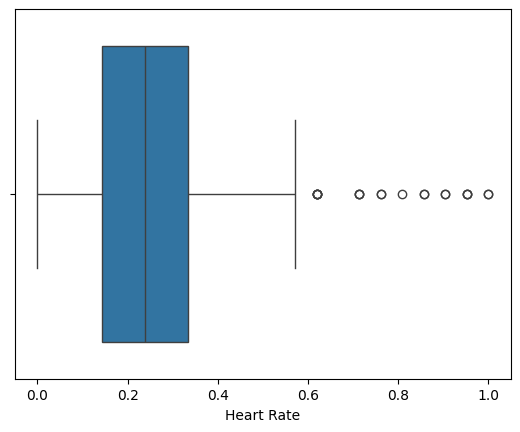

In [36]:
sns.boxplot(x=df['Heart Rate'])
plt.show()

Output tersebut menampilkan grafik boxplot dari variabel *Heart Rate*. Grafik ini digunakan untuk melihat sebaran data serta mendeteksi adanya nilai ekstrem (outlier).

Pada boxplot, nilai yang berada di luar garis batas (whisker) dapat dianggap sebagai outlier. Dengan visualisasi ini, dapat diketahui apakah terdapat data detak jantung yang menyimpang dari sebagian besar data.

Langkah ini penting untuk memastikan bahwa data yang digunakan tidak mengandung nilai yang dapat mempengaruhi hasil analisis secara signifikan.

In [37]:
df.info()
df.isnull().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Person ID                        374 non-null    int64  
 1   Gender                           374 non-null    int64  
 2   Age                              374 non-null    float64
 3   Sleep Duration                   374 non-null    float64
 4   Quality of Sleep                 374 non-null    int64  
 5   Physical Activity Level          374 non-null    int64  
 6   Stress Level                     374 non-null    int64  
 7   Heart Rate                       374 non-null    float64
 8   Daily Steps                      374 non-null    float64
 9   Systolic                         374 non-null    int64  
 10  Diastolic                        374 non-null    int64  
 11  Occupation_Accountant            374 non-null    bool   
 12  Occupation_Doctor     

,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,...,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_No Disorder,Sleep Disorder_Sleep Apnea
0,1,0,0.00000,0.111111,6,42,6,0.571429,0.171429,126,...,False,True,False,False,False,False,True,False,True,False
1,2,0,0.03125,0.148148,6,60,8,0.476190,1.000000,125,...,False,False,False,True,False,False,False,False,True,False
2,3,0,0.03125,0.148148,6,60,8,0.476190,1.000000,125,...,False,False,False,True,False,False,False,False,True,False
3,4,0,0.03125,0.037037,4,30,8,0.952381,0.000000,140,...,False,False,False,False,False,True,False,False,False,True
4,5,0,0.03125,0.037037,4,30,8,0.952381,0.000000,140,...,False,False,False,False,False,True,False,False,False,True


Output tersebut menunjukkan kondisi akhir dataset setelah seluruh proses preprocessing dilakukan. Dataset memiliki 374 data dengan 29 kolom, yang sebagian besar sudah dalam bentuk numerik (int dan float) serta beberapa dalam bentuk boolean hasil encoding.

Selain itu, hasil `isnull().sum()` menunjukkan bahwa tidak terdapat lagi missing value pada semua kolom, sehingga data sudah bersih dan lengkap. Tampilan `df.head()` juga memperlihatkan bahwa struktur data sudah rapi dan siap digunakan untuk analisis lebih lanjut.

Dengan demikian, dataset telah berhasil diproses dan siap digunakan pada tahap berikutnya, seperti analisis atau pemodelan.

## Kesimpulan

Setelah dilakukan preprocessing, data telah bersih dari missing value,
data kategorik telah diubah menjadi numerik, dan data telah dinormalisasi.
Dataset siap digunakan untuk analisis lebih lanjut.

Berdasarkan proses preprocessing yang telah dilakukan, dataset *Sleep Health and Lifestyle* berhasil dibersihkan dan dipersiapkan untuk analisis lebih lanjut. Tahapan yang dilakukan meliputi penanganan missing value, transformasi data, encoding variabel kategorik, serta normalisasi data numerik.

Hasil akhir menunjukkan bahwa seluruh data sudah dalam format yang sesuai, tidak terdapat nilai kosong, serta memiliki struktur yang lebih rapi dan terorganisir. Dengan demikian, dataset telah siap digunakan untuk tahap analisis atau pemodelan selanjutnya sehingga diharapkan dapat menghasilkan hasil yang lebih akurat dan valid.